# Complex Landscape

In gradient ascent, we use this formula to re-calculate the start points:

Do xnew = x + η · ∇f(x) where η is a learning rate and ∇ denotes the gradient
operator

In [23]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np
import random as rand

In [24]:
"COMPLEX LS"
# Definition of Complex landscape
def ComplexLandscape(x, y):
    return 4*(1-x)**2*np.exp(-(x**2)-(y+1)**2) -15*(x/5 - x**3 - y**5)*np.exp(-x**2-y**2) -(1./3)*np.exp(-(x+1)**2 - y**2)-1*(2*(x-3)**7 -0.3*(y-4)**5+(y-3)**9)*np.exp(-(x-3)**2-(y-3)**2)

# Definition of gradient of Complex landscape
def ComplexLandscapeGrad(x, y):
    g = np.zeros(2)
    g[0]=-8* np.exp(-(x**2)-(y+1)**2)*((1-x)+x*(1-x)**2)-15* np.exp(-x**2-y**2)*((0.2-3*x**2) -2*x*(x/5 - x**3 - y**5)) +(2./3)*(x+1)* np.exp(-(x+1)**2 - y**2)-1* np.exp(-(x-3)**2-(y-3)**2)*(14*(x-3)**6-2*(x-3)*(2*(x-3)**7-0.3*(y-4)**5+(y-3)**9))
    g[1]=-8*(y+1)*(1-x)**2* np.exp(-(x**2)-(y+1)**2) -15* np.exp(-x**2-y**2)*(-5*y**4 -2*y*(x/5 - x**3 - y**5)) +(2./3)*y* np.exp(-(x+1)**2 - y**2)-1* np.exp(-(x-3)**2-(y-3)**2)*((-1.5*(y-4)**4+9*(y-3)**8)-2*(y-3)*(2*(x-3)**7-0.3*(y-4)**5+(y-3)**9))
    return g

In [25]:
# Function to draw a surface (equivalent to ezmesh in Matlab)
# See argument cmap of plot_surface instruction to adjust color map (if so desired)
def DrawSurface(fig, varxrange, varyrange, function):
    """Function to draw a surface given x,y ranges and a function."""
    ax = fig.gca(projection='3d')
    xx, yy = np.meshgrid(varxrange, varyrange, sparse=False)
    z = function(xx, yy)
    surface = ax.plot_surface(xx, yy, z, alpha = 0.3,cmap=cm.coolwarm,
                       linewidth=100, antialiased=True) # color map can be adjusted, or removed! 
    fig.colorbar(surface, shrink=0.5, aspect=5)
    fig.canvas.draw()
    return ax

## Gradient Ascent

In [26]:
# Function implementing gradient ascent
def GradAscent(StartPt,NumSteps,LRate):
    
    for i in range(NumSteps):
        # TO DO: Calculate the 'height' at StartPt using SimpleLandscape or ComplexLandscape
        height = ComplexLandscape(StartPt[0],StartPt[1])
        
        # TO DO: Plot point on the landscape 
        ax.scatter(StartPt[0], StartPt[1], height)
        
        # TO DO: Calculate the gradient at StartPt using SimpleLandscapeGrad or ComplexLandscapeGrad
        gradient = ComplexLandscapeGrad(StartPt[0],StartPt[1])
        
        # TO DO: Calculate the new point and update StartPt
        StartPt += StartPt + LRate * gradient
        
        # Ensure StartPt is within the specified bounds (un/comment relevant lines)
        StartPt = np.maximum(StartPt,[-3,-3])
        StartPt = np.minimum(StartPt,[7,7])

## Implementation

GO:  10
inital starting points (x,y):
 [-2.15, -1.12]


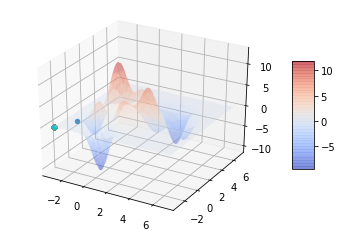

In [32]:
# Template 
# Plot the landscape (un/comment relevant line)
x = -3
y = 7

fig = plt.figure()
ax = DrawSurface(fig, np.arange(x,y+0.025,0.025), np.arange(x,y+0.025,0.025), ComplexLandscape)

# Enter maximum number of iterations of the algorithm, learning rate and mutation range
NumSteps=50
LRate=5.0 #**was 0.35

# TO DO: choose a random starting point with x and y in the range (-3,7) for complex landscape
StartPt = [round(rand.uniform(x,y),2),round(rand.uniform(x,y),2)]
GlobalOptimum = abs(x)+abs(y)
print("GO: ",GlobalOptimum)
print("inital starting points (x,y):\n", StartPt)

# Find maximum (un/comment relevant line)
GradAscent(StartPt,NumSteps,LRate)

## Gradient Ascent 2

In [18]:
# Function implementing gradient ascent
def GradAscent(xx,yy,NumSteps,LRate,x, y): #,NumGenerations
    
    StartPt = [] #start point will become an array or (x,y) after for loop
    prevHeight = -99 #keep track of previous height
    CapIteration = 0.0 #keep track of iteration that reaches a constant height
    StopCapCount = False #counter to control if statement
    height = 0

    # iterate a number of steps  
    for i in range(len(xx)):
        for j in range(len(yy)):
            StartPt = [xx[i][j],yy[i][j]]

            for k in range(NumSteps):
                #Calculate 'height' at StartPt
                height = ComplexLandscape(StartPt[0],StartPt[1])

                #capture height so that we can track which height becomes constant
                if height != prevHeight:
                    prevHeight = height

                #if height becomes constant, capture the iteration number
                elif height == prevHeight and StopCapCount == False:
                    CapIteration = i+1
                    StopCapCount = True

                # TO DO: Plot point on the landscape 
                ax.scatter(StartPt[0], StartPt[1], height)

                #Calculate gradient at StartPt
                gradient = ComplexLandscapeGrad(StartPt[0],StartPt[1])

                # TO DO: Calculate the new point and update StartPt
                StartPt += StartPt + LRate * gradient

                # Ensure StartPt is within the specified bounds
                StartPt = np.maximum(StartPt,[x,x])
                StartPt = np.minimum(StartPt,[y,y])
        
    return 0, NumSteps

## Implementation 2

(0, 20)

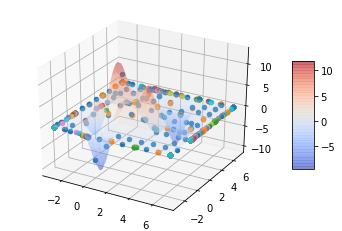

In [19]:
# Driver
#Keeping same landscape/starting point ranges as before
x = -3
c = 0.025
y = 7 + c

# Ploting the landscape with same function as before
#plt.ion()
fig = plt.figure()
ax = DrawSurface(fig, np.arange(x,y,c), np.arange(x,y,c), ComplexLandscape)

# maximum number of iterations and learning rate
NumSteps=20
LRate=0.01
#NumGenerations=50

#create arrays of x, y coordinates in specified range (x,y)
xvals = np.array([-3, -2, 1, 0, 1,2,3,4,5,6,7])
yvals = np.array([-3, -2, 1, 0, 1,2,3,4,5,6,7])
xx, yy = np.meshgrid(xvals, yvals)

GradAscent(xx,yy,NumSteps,LRate,x,y)

## Hill Climbing

In [8]:
# TO DO: Mutation function
# Returns a mutated point given the old point and the range of mutation
def Mutate(OldPt,MaxMutate):
    
    # TO DO: Select a random distance MutDist to mutate in the range (-MaxMutate,MaxMutate)
    MutDist = rand.uniform(-MaxMutate, MaxMutate)
    
    # TO DO: Randomly choose which element of OldPt to mutate and mutate by MutDist
    MutatedPt = rand.choice(OldPt) + MutDist
    
    return MutatedPt 

# Function implementing hill climbing
def HillClimb(StartPt,NumSteps,MaxMutate):
    
    for i in range(NumSteps):
        # TO DO: Calculate the 'height' at StartPt using SimpleLandscape or ComplexLandscape; necessary for plotting only
        height = ComplexLandscape(StartPt[0],StartPt[1])
        
        # TO DO: Plot point on the landscape using height
        # Use a markersize that you can see well enough (e.g., * in size 10)
        ax.scatter(StartPt[0], StartPt[1], height)
        
        # Mutate StartPt into NewPt
        NewPt = Mutate(np.copy(StartPt),MaxMutate) # Use copy because Python passes variables by references (see Mutate function)
        
        # Ensure NewPt is within the specified bounds (un/comment relevant lines)
        NewPt = np.maximum(NewPt,[-3,-3])
        NewPt = np.minimum(NewPt,[7,7])
               
        # TO DO: Calculate the height of the new point
        NewHeight = ComplexLandscape(NewPt[0],NewPt[1])
        
        # TO DO: Decide whether to update StartPt or not
        if NewHeight > height:
            StartPt = NewPt

## Implementation

inital starting points (x,y):
 [3.04, 3.63]


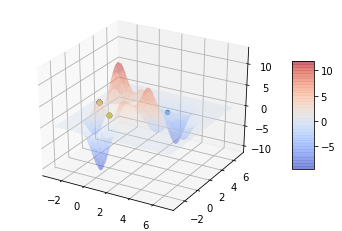

In [17]:
# Template 
# Plot the landscape (un/comment relevant line)
fig = plt.figure()
ax = DrawSurface(fig, np.arange(-3,7.025,0.025), np.arange(-3,7.025,0.025), ComplexLandscape)

# Enter maximum number of iterations of the algorithm, learning rate and mutation range
NumSteps=500
MaxMutate=15

# TO DO: choose a random starting point with x and y in the range (-2, 2) for simple landscape, (-3,7) for complex landscape
StartPt = [round(rand.uniform(-3,7),2),round(rand.uniform(-3,7),2)]
print("inital starting points (x,y):\n", StartPt)

# Find maximum (un/comment relevant line)
HillClimb(StartPt,NumSteps,MaxMutate)

## Hill Climbing 2

In [20]:
# TO DO: Mutation function
# Returns a mutated point given the old point and the range of mutation
def Mutate(OldPt,MaxMutate):
    
    # TO DO: Select a random distance MutDist to mutate in the range (-MaxMutate,MaxMutate)
    MutDist = rand.uniform(-MaxMutate, MaxMutate)
    
    # TO DO: Randomly choose which element of OldPt to mutate and mutate by MutDist
    MutatedPt = rand.choice(OldPt) + MutDist
    
    return MutatedPt 
          
# Function implementing hill climbing
def HillClimb(xx,yy,NumSteps,MaxMutate,GlobalOptimum,x,y):
    
    StartPt =[]
    prevHeight = -99
    CapIteration = 0.0
    StopCapCount = False
    height = 0
    
    # iterate a number of steps  
    for i in range(len(xx)):
        for j in range(len(yy)):
            StartPt = [xx[i][j],yy[i][j]]

            for k in range(NumSteps):

                # TO DO: Calculate the 'height' at StartPt using SimpleLandscape
                height = ComplexLandscape(StartPt[0],StartPt[1])

                if height != prevHeight:
                    prevHeight = height
                    CapIteration = i+1

                elif height == prevHeight and StopCapCount == False:
                    CapIteration = i+1
                    StopCapCount = True

                # TO DO: Plot point on the landscape using height
                ax.scatter(StartPt[0], StartPt[1], height)

                # Mutate StartPt into NewPt
                # Use copy because Python passes variables by references
                NewPt = Mutate(np.copy(StartPt),MaxMutate)

                # Ensure NewPt is within the specified bounds
                NewPt = np.maximum(NewPt,[x,x])
                NewPt = np.minimum(NewPt,[y,y])

                # TO DO: Calculate the height of the new point
                NewHeight = ComplexLandscape(NewPt[0],NewPt[1])

                # TO DO: Decide whether to update StartPt or not
                if NewHeight > height:
                    StartPt = NewPt
    
    return 0, NumSteps

## Implementation 2

(0, 100)

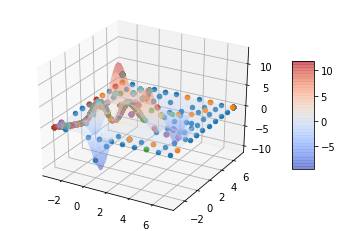

In [21]:
# Driver
#Keeping same landscape/starting point ranges as before
x = -3
c = 0.025
y = 7 + c

# Ploting the landscape with same function as before
#plt.ion()
fig = plt.figure()
ax = DrawSurface(fig, np.arange(x,y,c), np.arange(x,y,c), ComplexLandscape)

# maximum number of iterations and learning rate
NumSteps=20
MaxMutate=15
#NumGenerations=50

#create arrays of x, y coordinates in specified range (x,y)
xvals = np.array([-3, -2, 1, 0, 1,2,3,4,5,6,7])
yvals = np.array([-3, -2, 1, 0, 1,2,3,4,5,6,7])
xx, yy = np.meshgrid(xvals, yvals)

HillClimb(xx,yy,NumSteps,MaxMutate,GlobalOptimum,x,y)